# Homework 3 — Flower Architectures

**Oxford Flowers 102 · DataLoader · exact VGG11 · DenseNet from verified components**

Work from top to bottom. Every component has an immediate public check; do not continue when a check fails. Keep the official dataset splits unchanged.

In [ ]:
from __future__ import annotations

import math
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision.datasets import Flowers102
from torchvision.models import VGG11_Weights, vgg11
from torchvision.transforms import v2

SEED = 23
DATA_DIR = Path(os.environ.get("COURSE_DATA_DIR", "data"))
BATCH_SIZE = 32
IMAGE_SIZE = 224
NUM_CLASSES = 102
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print("PyTorch:", torch.__version__, "· device:", DEVICE)

## 1 · Data: inspect before training

The model contract is a batch shaped `(N, 3, 224, 224)`, normalized with the ImageNet statistics used by the official VGG11 weights. Training views may vary; validation and test views must be deterministic.

In [ ]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def make_eval_transform():
    # TODO: image conversion, Resize(256), CenterCrop(224), float scaling, normalization.
    raise NotImplementedError

def make_train_transform():
    # TODO: image conversion, RandomResizedCrop(224, scale=(0.7, 1.0)),
    # horizontal flip, float scaling, normalization.
    raise NotImplementedError

In [ ]:
probe = np.zeros((300, 260, 3), dtype=np.uint8)
for transform in (make_train_transform(), make_eval_transform()):
    output = transform(probe)
    assert output.shape == (3, IMAGE_SIZE, IMAGE_SIZE)
    assert output.dtype == torch.float32
print("✓ transforms satisfy the model input contract")

In [ ]:
# TODO: instantiate train, val, and test using the official split names.
# Only train receives the stochastic transform. Set download=True.
train_set = ...
val_set = ...
test_set = ...

# TODO: training shuffles; validation and test do not.
loader_kwargs = {"batch_size": BATCH_SIZE, "num_workers": 2,
                 "pin_memory": torch.cuda.is_available()}
train_loader = ...
val_loader = ...
test_loader = ...

In [ ]:
assert (len(train_set), len(val_set), len(test_set)) == (1020, 1020, 6149)
images, labels = next(iter(train_loader))
assert images.ndim == 4 and images.shape[1:] == (3, 224, 224)
assert labels.shape == (images.shape[0],) and labels.dtype == torch.long
assert 0 <= labels.min() and labels.max() < NUM_CLASSES
print("✓ official splits and batch contract:", images.shape, labels.shape)

### Visual target

Your result should be a balanced 3 × 4 gallery: twelve denormalized photographs, one readable category name per image, and no axes. The exact flowers vary because the training loader shuffles.

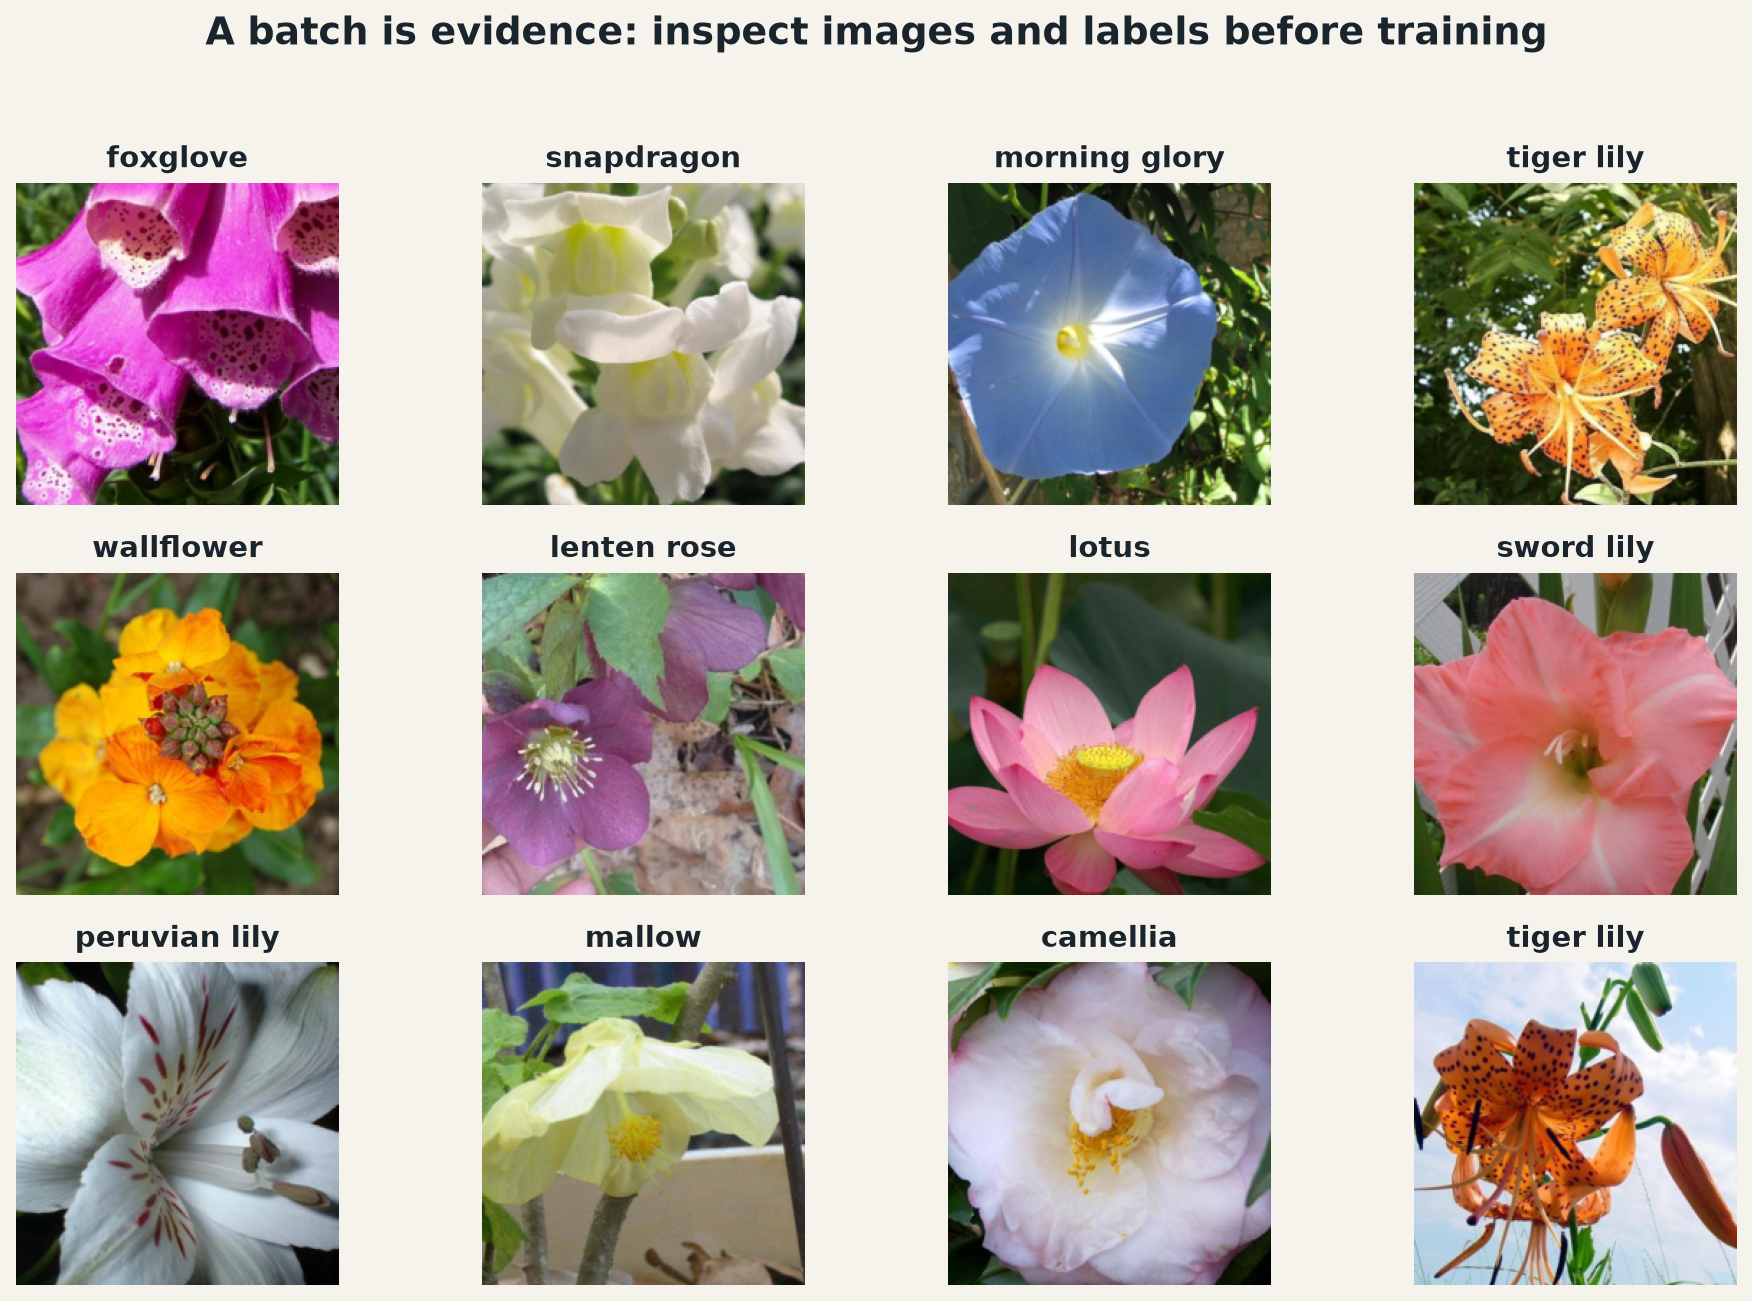

In [ ]:
FLOWER_NAMES = [
    "pink primrose", "hard-leaved pocket orchid", "canterbury bells", "sweet pea",
    "english marigold", "tiger lily", "moon orchid", "bird of paradise", "monkshood",
    "globe thistle", "snapdragon", "colt's foot", "king protea", "spear thistle",
    "yellow iris", "globe-flower", "purple coneflower", "peruvian lily", "balloon flower",
    "giant white arum lily", "fire lily", "pincushion flower", "fritillary", "red ginger",
    "grape hyacinth", "corn poppy", "prince of wales feathers", "stemless gentian",
    "artichoke", "sweet william", "carnation", "garden phlox", "love in the mist",
    "mexican aster", "alpine sea holly", "ruby-lipped cattleya", "cape flower",
    "great masterwort", "siam tulip", "lenten rose", "barbeton daisy", "daffodil",
    "sword lily", "poinsettia", "bolero deep blue", "wallflower", "marigold",
    "buttercup", "oxeye daisy", "common dandelion", "petunia", "wild pansy",
    "primula", "sunflower", "pelargonium", "bishop of llandaff", "gaura", "geranium",
    "orange dahlia", "pink-yellow dahlia", "cautleya spicata", "japanese anemone",
    "black-eyed susan", "silverbush", "californian poppy", "osteospermum",
    "spring crocus", "bearded iris", "windflower", "tree poppy", "gazania", "azalea",
    "water lily", "rose", "thorn apple", "morning glory", "passion flower", "lotus",
    "toad lily", "anthurium", "frangipani", "clematis", "hibiscus", "columbine",
    "desert-rose", "tree mallow", "magnolia", "cyclamen", "watercress", "canna lily",
    "hippeastrum", "bee balm", "ball moss", "foxglove", "bougainvillea", "camellia",
    "mallow", "mexican petunia", "bromelia", "blanket flower", "trumpet creeper",
    "blackberry lily",
]

def denormalize(batch):
    mean = torch.tensor(IMAGENET_MEAN).view(1, 3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(1, 3, 1, 1)
    return (batch.cpu() * std + mean).clamp(0, 1)

def show_batch(loader, count=12):
    # TODO: fetch one batch, denormalize it, and draw a 3 × 4 labeled gallery.
    raise NotImplementedError

fig = show_batch(train_loader)
assert len(fig.axes) == 12
assert all(not ax.axison for ax in fig.axes)
assert all(ax.get_title() for ax in fig.axes)
plt.show()
print("✓ batch audit is readable")

## 2 · VGG11: exactness makes transfer possible

The object graph must match TorchVision—not only the idea of VGG. `StudentVGG.features`, `avgpool`, and `classifier` own the parameters, and their names determine the `state_dict` keys.

```text
StudentVGG
├── features   ← configuration A: Conv/ReLU and MaxPool modules
├── avgpool    ← fixed 7 × 7 feature grid
└── classifier ← 25088 → 4096 → 4096 → 1000
```

In [ ]:
VGG_A = [64, "M", 128, "M", 256, 256, "M", 512, 512, "M", 512, 512, "M"]

def make_vgg_features(config):
    # TODO: "M" creates MaxPool2d(2, 2); an integer creates Conv2d(3×3,
    # padding=1) followed by ReLU(inplace=True). Track input channels.
    raise NotImplementedError

In [ ]:
features = make_vgg_features(VGG_A)
with torch.no_grad():
    feature_output = features(torch.randn(2, 3, 224, 224))
assert feature_output.shape == (2, 512, 7, 7)
assert sum(isinstance(m, nn.Conv2d) for m in features) == 8
assert sum(isinstance(m, nn.MaxPool2d) for m in features) == 5
print("✓ configuration A produces the expected VGG11 feature map")

In [ ]:
class StudentVGG(nn.Module):
    def __init__(self, num_classes=1000, dropout=0.5):
        super().__init__()
        # TODO: create attributes named features, avgpool, and classifier.
        # Match torchvision.models.vgg11 exactly.
        raise NotImplementedError

    def forward(self, x):
        # TODO: features → avgpool → flatten → classifier
        raise NotImplementedError

In [ ]:
torch.manual_seed(SEED)
student_vgg = StudentVGG()
reference_vgg = vgg11(weights=None)
assert list(student_vgg.state_dict()) == list(reference_vgg.state_dict())
assert sum(p.numel() for p in student_vgg.parameters()) == 132_863_336
with torch.inference_mode():
    assert student_vgg(torch.randn(1, 3, 224, 224)).shape == (1, 1000)
print("✓ module names, shapes, and parameter count match TorchVision VGG11")

### Strongest test: load the official weights

Load `VGG11_Weights.DEFAULT` into your own class with `strict=True`. Then compare its logits with TorchVision's model on the same tensor. Only after exact equivalence is established should you replace the classification head.

In [ ]:
weights = VGG11_Weights.DEFAULT
official_vgg = vgg11(weights=weights).eval()

# TODO: strictly load official_vgg.state_dict() into student_vgg.
# Compare both models' logits on the same random input, then replace only the
# final Linear layer for 102 classes. Freeze every parameter in features.
raise NotImplementedError

In [ ]:
assert student_vgg.classifier[-1].out_features == NUM_CLASSES
assert not any(p.requires_grad for p in student_vgg.features.parameters())
assert all(p.requires_grad for p in student_vgg.classifier[-1].parameters())
with torch.inference_mode():
    assert student_vgg(torch.randn(2, 3, 224, 224)).shape == (2, NUM_CLASSES)
print("✓ official weights transferred; the new 102-class head is trainable")

## 3 · DenseNet: build upward from one concatenation

Each dense layer stores operations, not copies of earlier feature maps. During `forward`, it receives the accumulated tensor, creates `growth_rate` new channels, and concatenates input and new evidence.

```text
x (C channels) ───────────────┐
  └─ BN → ReLU → 1×1 → BN → ReLU → 3×3 ── new (k channels)
                              └─ concatenate → C + k channels
```

In [ ]:
class DenseLayer(nn.Module):
    def __init__(self, in_channels, growth_rate, bottleneck_factor=4, drop_rate=0.0):
        super().__init__()
        # TODO: BN-ReLU-1×1 bottleneck then BN-ReLU-3×3 growth convolution.
        # Both convolutions use bias=False. Store drop_rate.
        raise NotImplementedError

    def forward(self, x):
        # TODO: create new_features, optionally dropout during training,
        # then concatenate x and new_features on the channel dimension.
        raise NotImplementedError

In [ ]:
def expected_dense_layer_parameters(in_channels, growth_rate, bottleneck_factor=4):
    hidden = bottleneck_factor * growth_rate
    # two BN affine vectors + two bias-free convolution kernels
    return 2*in_channels + in_channels*hidden + 2*hidden + hidden*growth_rate*3*3

x = torch.randn(2, 24, 16, 16)
layer = DenseLayer(24, growth_rate=12)
y = layer(x)
assert y.shape == (2, 36, 16, 16)
assert torch.equal(y[:, :24], x)
assert sum(p.numel() for p in layer.parameters()) == expected_dense_layer_parameters(24, 12)
print("✓ DenseLayer preserves old features and contributes exactly k new channels")

In [ ]:
class DenseBlock(nn.Module):
    def __init__(self, num_layers, in_channels, growth_rate, drop_rate=0.0):
        super().__init__()
        # TODO: use nn.ModuleList. Layer i receives in_channels + i*growth_rate.
        # Store the final channel count as self.out_channels.
        raise NotImplementedError

    def forward(self, x):
        # TODO: feed the growing tensor through each layer.
        raise NotImplementedError

In [ ]:
block = DenseBlock(num_layers=4, in_channels=24, growth_rate=12)
assert isinstance(block.layers, nn.ModuleList)
assert [m.norm1.num_features for m in block.layers] == [24, 36, 48, 60]
assert block.out_channels == 72
assert block(torch.randn(2, 24, 16, 16)).shape == (2, 72, 16, 16)
print("✓ DenseBlock channel growth: 24 → 36 → 48 → 60 → 72")

In [ ]:
class Transition(nn.Sequential):
    def __init__(self, in_channels, compression=0.5):
        # TODO: validate 0 < compression <= 1, compute floor(compression*C),
        # then BN → ReLU → bias-free 1×1 Conv → AvgPool2d(2, 2).
        # Store the result as self.out_channels.
        raise NotImplementedError

In [ ]:
transition = Transition(72, compression=0.5)
assert transition.out_channels == 36
assert transition(torch.randn(2, 72, 16, 16)).shape == (2, 36, 8, 8)
assert sum(p.numel() for p in transition.parameters()) == 2*72 + 72*36
try:
    Transition(72, compression=0)
    raise AssertionError("compression=0 must be rejected")
except ValueError:
    pass
print("✓ Transition compresses channels and halves spatial resolution")

### Assemble the network

The network owns a stem, an alternating sequence of dense blocks and transitions, a final normalization, and a classifier. Adaptive pooling makes the final spatial size independent of the input resolution.

In [ ]:
class CompactDenseNet(nn.Module):
    def __init__(self, growth_rate=12, block_config=(4, 6, 8),
                 initial_channels=24, compression=0.5, num_classes=102):
        super().__init__()
        # TODO: bias-free Conv2d(3, initial_channels, 3, padding=1) stem;
        # a ModuleList alternating blocks and transitions (no transition after
        # the last block); final BN; AdaptiveAvgPool2d(1); Linear classifier.
        # Track the channel arithmetic as self.num_features.
        raise NotImplementedError

    def forward(self, x):
        # TODO: stem → stages → final BN/ReLU → pool → flatten → classifier.
        raise NotImplementedError

In [ ]:
dense_model = CompactDenseNet()
assert dense_model.num_features == 150  # 24→72→36→108→54→150
with torch.inference_mode():
    assert dense_model(torch.randn(2, 3, 224, 224)).shape == (2, NUM_CLASSES)
print("✓ complete DenseNet returns 102 flower logits")

### Independent parameter audit

Do not verify a model with the same loop that built it. Derive the expected count from channel transitions, including normalization affine parameters and the classifier bias.

In [ ]:
def expected_compact_densenet_parameters(growth_rate=12, block_config=(4, 6, 8),
                                         initial_channels=24, compression=0.5,
                                         num_classes=102):
    # TODO: independently sum stem, every DenseLayer, every Transition,
    # final BN, and classifier parameters. Do not inspect a model object.
    raise NotImplementedError

expected = expected_compact_densenet_parameters()
observed = sum(p.numel() for p in dense_model.parameters())
assert expected == observed, (expected, observed)
print(f"✓ independent parameter audit: {observed:,}")

In [ ]:
def one_learning_step(model, num_classes=NUM_CLASSES):
    model.train().to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
    inputs = torch.randn(4, 3, 64, 64, device=DEVICE)
    targets = torch.randint(num_classes, (4,), device=DEVICE)
    before = [p.detach().clone() for p in model.parameters()]
    optimizer.zero_grad(set_to_none=True)
    loss = nn.functional.cross_entropy(model(inputs), targets)
    loss.backward()
    optimizer.step()
    changed = sum(not torch.equal(a, b.detach()) for a, b in zip(before, model.parameters()))
    return float(loss), changed

loss, changed = one_learning_step(dense_model)
assert math.isfinite(loss) and changed > 0
print(f"✓ learning step: loss={loss:.3f}; changed tensors={changed}")

## 4 · Controlled comparison

Train (1) the pretrained VGG11 with frozen feature extractor and (2) the compact DenseNet from scratch. Use the same official splits, metric, and evaluation function. Suggested starting points:

| Model | Optimizer | Learning rate | Epochs |
|---|---|---:|---:|
| pretrained VGG11 head | AdamW | `1e-3` | 5 |
| compact DenseNet | AdamW | `3e-4` | 15 |

Report trainable parameters, best validation accuracy, corresponding test accuracy, and training time. Plot learning curves and show at least six test errors. Explain what can be attributed to pretrained representations, what may be capacity, and what the experiment cannot establish.

In [ ]:
# TODO: write or reuse your course train/evaluate functions, run both models,
# and assemble one comparison table with the columns below.
comparison = pd.DataFrame(columns=[
    "model", "trainable_parameters", "best_val_accuracy",
    "test_accuracy", "training_minutes"
])
comparison

## Submission checklist

- [ ] Restarted the kernel and ran every cell in order.
- [ ] All transform, split, loader, and gallery checks pass.
- [ ] Student VGG11 matches TorchVision and loads official weights strictly.
- [ ] DenseLayer, DenseBlock, Transition, complete-model, and learning checks pass.
- [ ] Analytical and observed DenseNet parameter counts agree.
- [ ] Curves, comparison table, error gallery, and concise interpretation are present.

### References

- [Oxford VGG — 102 Category Flower Dataset](https://www.robots.ox.ac.uk/~vgg/data/flowers/102/)
- [TorchVision — Flowers102](https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.Flowers102.html)
- [Simonyan & Zisserman (2015) — VGG](https://arxiv.org/abs/1409.1556)
- [Huang et al. (2017) — DenseNet](https://arxiv.org/abs/1608.06993)